# Mentoring 4 - Fraud Analytics
---
Mohammad Rifqi Zein \
Mentoring Session - Job Preparation Program - Pacmann AI

In [2]:
# Load package
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

## 1. Case: Human In The Loop
---

- You work as a data scientist for an online retail company that has been build machine learning model that could detect fraudulent transaction early in the process 
- However, you find that the prediction of the model still misclassifies the transaction that needs to be flagged for further investigation and helps to prevent fraudulent transactions from being approved.
- You are considered to simulate a human-in-the-loop (HITL) mechanism to improve the prediction. You are willing to involve experts in the evaluation phase. You are going to determine the low confidence prediction, ask experts to annotate them, and assess the comparison performance before and after the HITL mechanism.
- The dataset: [download here](https://drive.google.com/file/d/1bYYwkzipAQe7dTEhLazIlNxug6wNQXhV/view?usp=sharing)

## 2. Dataset Description
---

|Column|Description|
|:--|:--|
|`Transaction ID`|A unique identifier for each transaction.|
|`Transaction Amount`|The total amount of money exchanged in the transaction.|
|`Account Age Days`|The age of the customer's account in days at the time of the transaction.|
|`Transaction Hour`|The hour of the day when the transaction occurred.|
|`Is Fraudulent`|A binary indicator of whether the transaction is fraudulent (1 for fraudulent, 0 for legitimate).|
|`y_pred`|Prediction from Machine Learning (1 for predicted as fraudulent, 0 for predicted as legitimate).|
|`y_pred_proba`|Probability prediction from Machine Learning.|

## 3. The Tools
---

You can use python to do this exercise.

## 4. Your Task
---

## Question 1: Introduction

Human-in-the-Loop (HITL) is an approach in machine learning (ML) where humans actively participate in the model training, evaluation, or decision-making process to improve performance and reliability. 


In this case experts would participate to  give  annotations of fraud class where the model could misclassify the transaction. 


Task: 
- Determine which part of data that needs to be labeled by experts. 
- Hint: Identify low-confidence predictions using uncertainty sampling techniques

### **Importing Data**

In [13]:
# read dataset function
def read_data(path):
    """
    Reads a CSV file at the given path,
    and returns its contents as a pandas DataFrame.

    Parameters
    ----------
    path : str
        The sample data input path (csv format)

    Return
    ------
    df : pd.DataFrame
        The sample data input
    """
    # Read data
    df = pd.read_csv(path)

    # Validate
    print('Data shape:', df.shape)

    return df

In [14]:
# Dataset name / Path
path = 'transaction_sample.csv'

# Read the data
df = read_data(path = path)
df.head()

Data shape: (4727, 7)


,Transaction ID,Transaction Hour,Transaction Amount,Account Age Days,Is Fraudulent,y_pred,y_pred_proba
0,34bf1ce8-118a-467b-a319-9e7e02d5845c,5,79.02,216,0,0,0.114403
1,bd73ee3b-34da-4dd5-a494-1e0964045a47,22,89.29,198,0,0,0.172854
2,65db4491-943b-49f1-96f6-948b677ae953,10,1070.04,148,0,0,0.389952
3,bc3198c1-64f6-473b-bcbc-dfdfe59dc64d,21,281.05,35,0,0,0.228857
4,f3dd988b-ffc4-4d5e-95fe-e9760f1b52ab,11,69.61,271,0,0,0.357841


Kemudian kita cek missing values dan duplicates.

In [16]:
print("Number of missing values:\n", df.isnull().sum())
print("Number of duplicates:", df.duplicated().sum())

Number of missing values:
 Transaction ID        0
Transaction Hour      0
Transaction Amount    0
Account Age Days      0
Is Fraudulent         0
y_pred                0
y_pred_proba          0
dtype: int64
Number of duplicates: 0


Tidak ada data yang hilang ataupun duplikat. \
Kemudian kita cek apakah semua nilai numerik bernilai positif (karena tidak mungkin umur dan jumlah uang bernilai negatif) dan cek apakah y_pred_proba  bernilai antara 0 dan 1 serta cek juga apakah semua nilai `Is Fraudulent` dan `y_pred` bernilai 0 dan 1.

In [18]:
numeric_cols = ['Transaction Hour', 'Transaction Amount', 'Account Age Days']
negative_counts = (df[numeric_cols] < 0).sum()

print("Number of negative values:")
print(negative_counts)

invalid_proba = ((df['y_pred_proba'] < 0)|(df['y_pred_proba'] > 1)).sum()
print("Number of invalid y_pred_proba:")
print(invalid_proba)

print("Unique values of Is Fraudulent:", df['Is Fraudulent'].unique())
print("Unique values of y_pred:", df['y_pred'].unique())

Number of negative values:
Transaction Hour      0
Transaction Amount    0
Account Age Days      0
dtype: int64
Number of invalid y_pred_proba:
0
Unique values of Is Fraudulent: [0 1]
Unique values of y_pred: [0 1]


Tidak ada inkonsistensi, jadi kita lanjut ke step berikutnya. \
Kita coba lihat distribusi y_pred_proba dengan histogram.

<Axes: xlabel='y_pred_proba', ylabel='Count'>

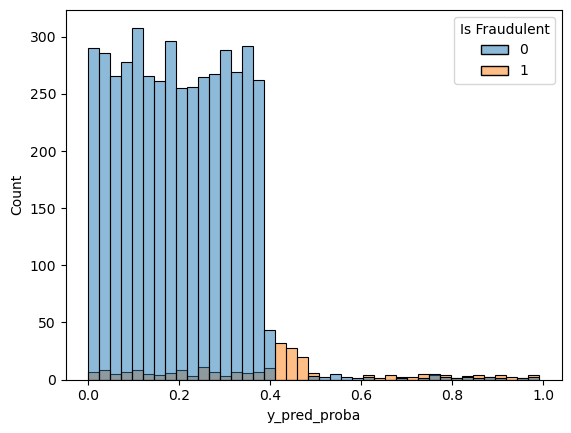

In [20]:
sns.histplot(data=df, x='y_pred_proba', hue='Is Fraudulent')

Dari hasil di atas, kita akan ambil 0.4 <= y_pred_proba <= 0.6 sebagai low confidence interval karena model masih ragu-ragu dalam menentukan apakah transaksi tersebut fraud atau tidak sehingga hasilnya belum pasti dan perlu dilabeli oleh expert.

## Question 2: Annotation

Assuming you are an expert, annotate the data which was previously selected. \
Task:
- Perform Exploratory Data Analysis (EDA) to detect patterns and insights from the dataset to help predicting fraud.
- Define expert rules based on EDA for annotation.
- Annotate whether fraud or non fraud on the previously selected uncertain transactions from Question 1 based on these rules.
- Update ‘y_ped’ where some parts of data are from the newly annotated data. Store to new columns named “y_pred_exp”. 

### Exploratory Data Analysis

Pertama, kita lihat distribusi variabel numerik terlebih dahulu pada low confidence interval.

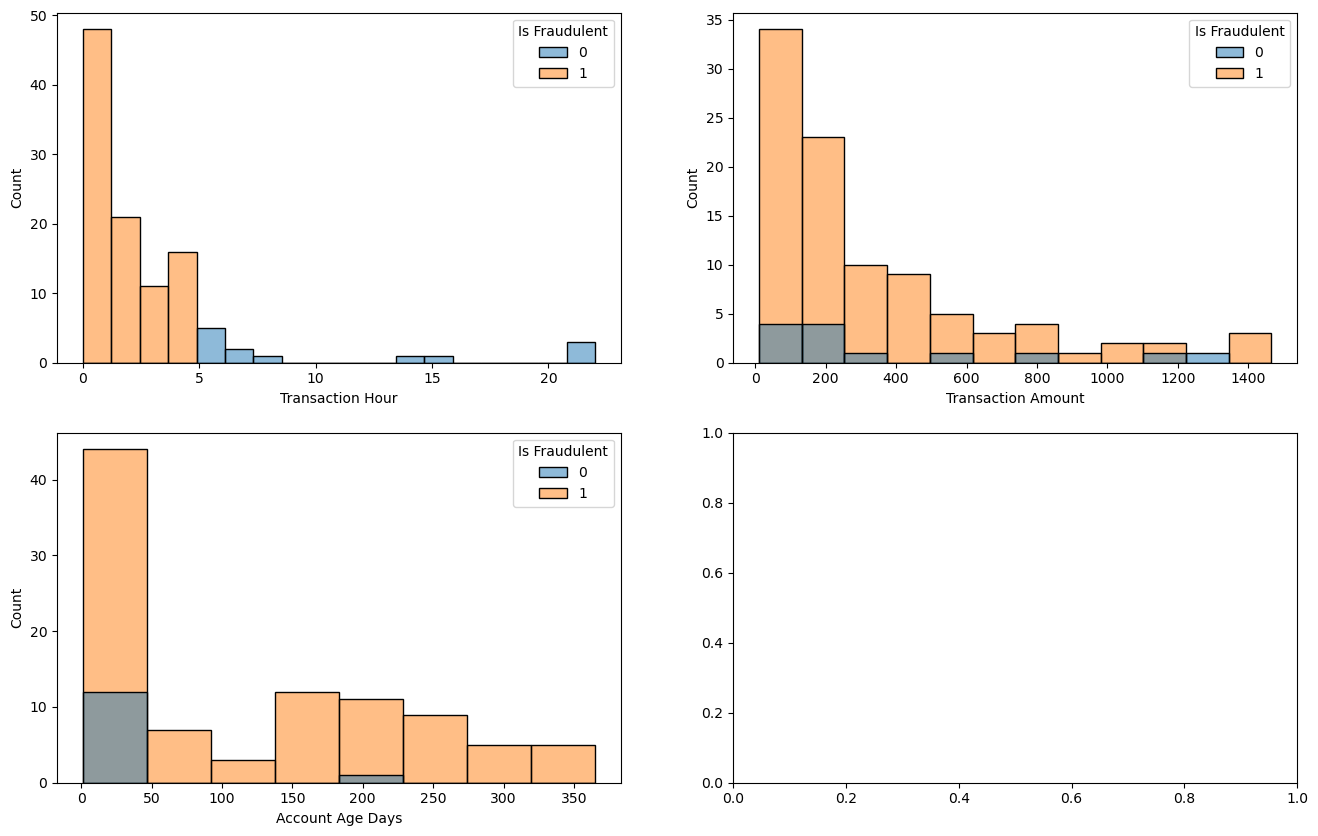

In [26]:
eda_df = df[(df['y_pred_proba'] >= 0.4) & (df['y_pred_proba'] <=0.6 )].copy()
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
cols_to_hist = numeric_cols

for i, col in enumerate(cols_to_hist):
    sns.histplot(data=eda_df, x=col, hue='Is Fraudulent', ax=axes.flatten()[i])

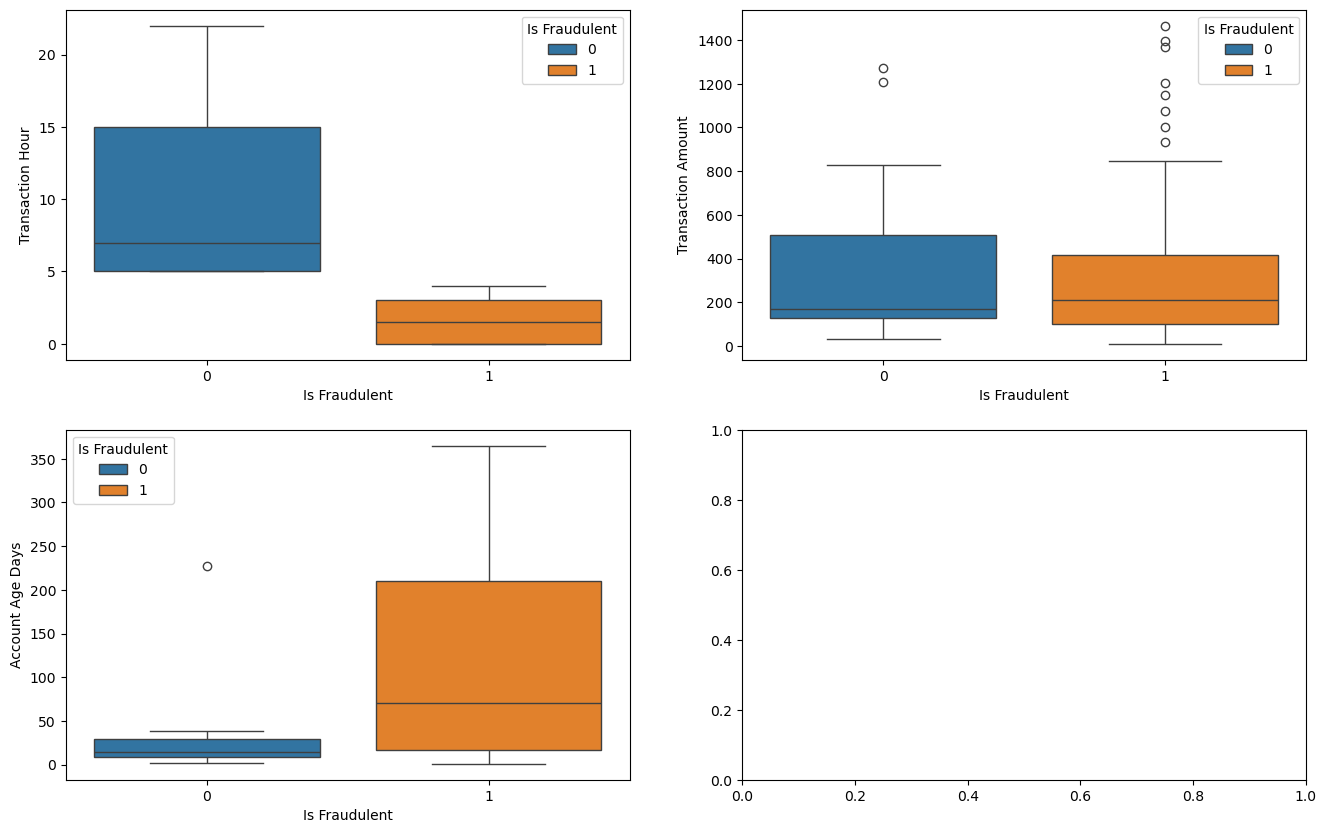

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, col in enumerate(cols_to_hist):
    sns.boxplot(data=eda_df, x='Is Fraudulent', hue='Is Fraudulent', y=col, ax=axes.flatten()[i])

Dari hasil di atas, dapat dilihat bahwa dalam data di low confidence interval:
- Tidak terlalu ada perbedaan distribusi yang signifikan untuk `Transaction Amount`.
- Transaksi dengan `Account Age Days` > 50 akan hampir selalu fraud.
- Transaksi dengan `Transaction Hour` < 5 akan selalu fraud. Kita hanya akan menggunakan kolom ini untuk anotasi fraud.

Dari hasil ini, maka selanjutnya kita akan tambahkan Expert Based Rules.

### Annotation

In [30]:
def expert_annotate(df):
    """
    Annotate data in low confidence interval

    Parameters
    ----------
    df : pd.DataFrame
        The sample data input

    Return
    ------
    df : pd.DataFrame
        The sample data output with column y_pred_exp
    """
    low_confidence = (df['y_pred_proba'] >= 0.4) & (df['y_pred_proba'] <=0.6)
    df_expert = df[low_confidence].copy()
    df_expert['expert_label'] = (df_expert['Transaction Hour'] < 5).astype(int)
    
    # Atur nilai awal y_pred_exp sama dengan y_pred
    df['y_pred_exp'] = df['y_pred']

    # Anotasi prediksi di area low confidence dengan label dari expert
    df.loc[low_confidence, 'y_pred_exp'] = df_expert['expert_label']
    return df

In [31]:
df = expert_annotate(df)
df

,Transaction ID,Transaction Hour,Transaction Amount,Account Age Days,Is Fraudulent,y_pred,y_pred_proba,y_pred_exp
0,34bf1ce8-118a-467b-a319-9e7e02d5845c,5,79.02,216,0,0,0.114403,0
1,bd73ee3b-34da-4dd5-a494-1e0964045a47,22,89.29,198,0,0,0.172854,0
2,65db4491-943b-49f1-96f6-948b677ae953,10,1070.04,148,0,0,0.389952,0
3,bc3198c1-64f6-473b-bcbc-dfdfe59dc64d,21,281.05,35,0,0,0.228857,0
4,f3dd988b-ffc4-4d5e-95fe-e9760f1b52ab,11,69.61,271,0,0,0.357841,0
...,...,...,...,...,...,...,...,...
4722,8bbaf2c3-5fef-4509-8d39-02974e37718a,13,326.91,64,0,0,0.266730,0
4723,2f9ec2dd-becf-474c-b656-0b88471ceac7,14,91.35,50,0,0,0.353650,0
4724,d5e45062-5e64-4f5e-95ee-afd163bd055d,2,67.59,236,0,0,0.091619,0
4725,94e8eac4-761d-403e-bc41-1539d3287302,7,319.15,28,0,0,0.082519,0


## Question 3: Evaluation

Task:
- Evaluate the result of prediction using ROC-AUC
  - Before HITL, using y_pred: the result of machine learning model only
  - After HITL (Incorporating the newly annotated data: y_pred_exp and reevaluating performance)
- Compare the model prediction time:
  - Before HITL (processing time per transaction is 0.00012 second).
  - After HITL (processing time per transaction including expert review).
- Calculate the false prediction cost, assuming the false positive cost and false negative cost are similar, that’s the amount of the transaction.
  - Before HITL
  - After HITL 
- Summarize in table and analyze the trade-off:
|Model|ROC AUC|FN Cost|FP Cost|Execution Time Cost|Total Cost|
|:--|:--|:--|:--|:--|:--|
|Machine Learning (ML)||||||
|ML + HITL||||||

  - Has the model improved significantly in fraud detection?
  - How much additional time does the human annotation process introduce?
  - Does the increase in fraud detection performance justify the additional cost of human intervention? Assuming the cost of execution time is \$0.01 per second

In [34]:
# 1. Menghitung ROC-AUC
roc_auc_ml = roc_auc_score(df['Is Fraudulent'], df['y_pred'])
roc_auc_hitl = roc_auc_score(df['Is Fraudulent'], df['y_pred_exp'])

# 2. Menghitung False Prediction Cost
fn_ml = (df['Is Fraudulent'] == 1) & (df['y_pred'] == 0)
fp_ml = (df['Is Fraudulent'] == 0) & (df['y_pred'] == 1)

fn_hitl = (df['Is Fraudulent'] == 1) & (df['y_pred_exp'] == 0)
fp_hitl = (df['Is Fraudulent'] == 0) & (df['y_pred_exp'] == 1)

# Hitung Cost (berdasarkan Transaction Amount)
fn_cost_ml = df.loc[fn_ml, 'Transaction Amount'].sum()
fp_cost_ml = df.loc[fp_ml, 'Transaction Amount'].sum()

fn_cost_hitl = df.loc[fn_hitl, 'Transaction Amount'].sum()
fp_cost_hitl = df.loc[fp_hitl, 'Transaction Amount'].sum()

# 3. Menghitung Execution Time Cost
total_transactions = len(df)
ml_time_per_tx = 0.00012

# Waktu ML murni
time_ml = total_transactions * ml_time_per_tx

# Waktu ML + HITL (Kita asumsikan Expert butuh 1 menit (60 detik) untuk melabeli transaksi yang ambigu dengan melihat Transaction Hour saja)
low_confidence = (df['y_pred_proba'] >= 0.4) & (df['y_pred_proba'] <=0.6)
expert_time_per_tx = 60
num_expert = low_confidence.sum()
time_hitl = time_ml + (num_expert * expert_time_per_tx)

# Hitung Execution Time Cost ($0.01 per second)
exec_cost_ml = time_ml * 0.01
exec_cost_hitl = time_hitl * 0.01

# 4. Hitung Total Cost
total_cost_ml = fn_cost_ml + fp_cost_ml + exec_cost_ml
total_cost_hitl = fn_cost_hitl + fp_cost_hitl + exec_cost_hitl

# 5. Membuat Tabel Summary
summary_data = {
    'Model': ['Machine Learning (ML)', 'ML + HITL'],
    'ROC AUC': [roc_auc_ml, roc_auc_hitl],
    'FN Cost': [f"${fn_cost_ml:,.2f}", f"${fn_cost_hitl:,.2f}"],
    'FP Cost': [f"${fp_cost_ml:,.2f}", f"${fp_cost_hitl:,.2f}"],
    'Execution Time Cost': [f"${exec_cost_ml:,.5f}", f"${exec_cost_hitl:,.2f}"],
    'Total Cost': [f"${total_cost_ml:,.2f}", f"${total_cost_hitl:,.2f}"]
}
print(f"Prediction Time before HITL: {time_ml} s.")
print(f"Prediction Time after HITL: {time_hitl} s.")
summary_df = pd.DataFrame(summary_data)
summary_df

Prediction Time before HITL: 0.56724 s.
Prediction Time after HITL: 6540.56724 s.


,Model,ROC AUC,FN Cost,FP Cost,Execution Time Cost,Total Cost
0,Machine Learning (ML),0.592125,"$66,660.13","$11,939.79",$0.00567,"$78,599.93"
1,ML + HITL,0.789494,"$35,202.90","$6,762.14",$65.41,"$42,030.45"


Dari hasil di atas, dapat dilihat bahwa:
- ROC-AUC meningkat sangat signifikan dari 0,59 menjadi 0,79. Artinya, kemampuan model menjadi jauh lebih baik dalam mendeteksi fraud setelah melakukan anotasi oleh expert dalam low confidence interval.
- Dengan asumsi expert butuh 1 menit (60 detik) untuk melabeli transaksi yang ambigu dengan cara melihat Transaction Hour saja, waktu prediksinya jauh lebih besar (6540 detik atau 109 menit) dibandingkan model tanpa HITL (kurang dari 1 detik).
- Namun, tambahan biaya Execution Time (sekitar \$`65.41`) untuk anotasi expert sangat sepadan untuk meningkatkan performa model dalam mendeteksi fraud. Dengan menggunakan model dengan HITL, total cost menjadi turun secara signifikan, dari \$`78.599` menjadi hanya \$`42.030` (turun 47% dari total cost tanpa HITL).

## 1. Case: Social Network Analysis
---

- You are a data scientist working in the fraud detection unit of a bank.
- Your task is to develop a robust fraud detection system using machine learning and incorporating features from social network analysis (SNA). 
- The bank has provided you with a synthetic dataset called BankSim, which simulates real-world banking transactions based on aggregated data from a bank in Spain.
- You need a better approach to identify hidden fraud patterns and improve your model's performance. Since fraudsters often collaborate in structured ways, you decide to model transactions as a network where: \
i.&ensp;&nbsp;Customers (nodes) are linked to merchants (nodes) based on transactions. \
ii.&ensp;Edges (connections) represent transactions between customers and merchants. \
iii. Some transactions are labeled as fraudulent, giving insight into fraudulent behavior.
- By analyzing these relationships, you aim to uncover hidden fraud patterns that traditional methods may miss.
- The dataset: [download here](https://drive.google.com/file/d/1mhs-tGPmxpoSx6NlQVYupAMaWABvdhrT/view?usp=sharing)

## 2. Dataset Description
---

|Column|Description|
|:--|:--|
|`step`|The time step at which the transaction occurs. This represents a unit of time in the simulation rather than a specific date.|
|`customer`|Unique identifier for the customer making the transaction. This helps track individual transaction behavior.|
|`age`|Age group of the customer (e.g., ‘0-20’, ‘21-30’, ‘31-40’, etc.). Instead of exact ages, the dataset provides age ranges.|
|`gender`|Gender of the customer, typically labeled as ‘M’ (Male) or ‘F’ (Female).|
|`merchant`|Unique identifier for the merchant where the transaction occurred. This helps analyze merchant-related fraud patterns.|
|`category`|The type of product or service involved in the transaction (e.g., ‘food’, ‘electronics’, ‘clothing’). This helps in identifying fraud patterns in specific industries.	
|`amount`|The monetary value of the transaction. Higher-than-usual amounts may indicate fraudulent behavior.|
|`fraud`|Target variable indicating whether the transaction is fraudulent (1) or legitimate (0). This is used for model training and evaluation.|

## 3. The Tools
---

You can use python to do this exercise.

## 4. Your Task
---

## Question 1: Type of Fraud in Network

- Explain the kind of fraud activities that could be found on the banking transaction in the data. e.g. Account Takeover (ATO) Fraud, etc. 
- Identify common fraud patterns in network structures.
  - Some customers have a high number of fraudulent transactions across multiple merchants. Find those high-risk customers by identifying the top three customers who are connected to the highest number of fraud cases.
  - Top three merchants that are frequently connected to fraudulent customers (customers whose transactions are all fraud). They might collaborate  to process fraudulent transactions, either by creating fake purchases or inflating transaction amounts.
- We can find the list of customers and merchants that we could then deny all the transactions and add them into the blacklist. Find the list of customers and merchants whose transactions are all fraudulent. 

### Importing Data

Sebelum itu, kita akan siapkan datanya terlebih dahulu.

In [47]:
# Dataset name / Path
path = 'bank_data.csv'

# Read the data
df = read_data(path = path)
df.head()

Data shape: (19966, 8)


,step,customer,age,gender,merchant,category,amount,fraud
0,86,C1372889664,5,F,M1823072687,es_transportation,3.13,0
1,26,C377075708,2,M,M348934600,es_transportation,27.11,0
2,39,C1871594117,1,M,M1823072687,es_transportation,27.32,0
3,176,C730142143,4,F,M348934600,es_transportation,37.87,0
4,155,C1385354747,4,M,M1823072687,es_transportation,32.33,0


Kemudian kita cek missing values dan duplicates.

In [49]:
print("Number of missing values:\n", df.isnull().sum())
print("Number of duplicates:", df.duplicated().sum())

Number of missing values:
 step        0
customer    0
age         0
gender      0
merchant    0
category    0
amount      0
fraud       0
dtype: int64
Number of duplicates: 293


Tidak ada data yang hilang ataupun duplikat. \
Kemudian kita cek apakah semua nilai numerik bernilai positif (karena tidak mungkin umur dan jumlah uang bernilai negatif) dan cek nilai tiap kategori serta cek juga apakah semua nilai `fraud` bernilai 0 dan 1.

In [51]:
numeric_cols = ['step', 'age', 'amount']
negative_counts = (df[numeric_cols] < 0).sum()

print("Number of negative values:")
print(negative_counts)

print("Unique values of age:", df['age'].unique())
print("Unique values of gender:", df['gender'].unique())
print("Unique values of category:", df['category'].unique())
print("Unique values of fraud:", df['fraud'].unique())

Number of negative values:
step      0
age       0
amount    0
dtype: int64
Unique values of age: [5 2 1 4 3 6 0]
Unique values of gender: ['F' 'M' 'U']
Unique values of category: ['es_transportation' 'es_barsandrestaurants' 'es_health' 'es_hyper'
 'es_food' 'es_wellnessandbeauty' 'es_hotelservices' 'es_tech'
 'es_fashion' 'es_sportsandtoys' 'es_travel' 'es_home' 'es_otherservices'
 'es_contents' 'es_leisure']
Unique values of fraud: [0 1]


Tidak ada inkonsistensi, jadi kita lanjut ke step berikutnya.

### Common Fraud Patterns

Jenis-jenis aktivitas fraud yang sering ditemukan di transaksi bank:
1. **Online Account Opening Fraud** (Penipuan Pembukaan Rekening Online): Penipu berhasil membuka rekening bank baru secara online menggunakan identitas palsu atau curian. Rekening ini bisa disalahgunakan menjadi rekening untuk menampung dana ilegal, pencucian uang, atau melakukan penipuan yang lain.
2. **Account Takeover Fraud** (Pengambilalihan Akun): Penipu secara ilegal mengambil kendali penuh atas rekening sah milik nasabah asli. Mereka biasanya mendapatkan detail login (username, PIN, password) melalui taktik phishing (seperti mengirim link palsu via WhatsApp/email) atau membeli data yang bocor di dark web. Begitu masuk, mereka akan menguras saldo, mentransfer dana, atau mengganti detail kontak agar nasabah asli tidak mendapat notifikasi.
3. **Malware Attacks** (Serangan Malware): Penipu menyusupkan virus atau software jahat (malware) ke HP atau komputer nasabah asli, bisa berupa aplikasi palsu (seperti file APK undangan pernikahan/kurir paket yang dikirim via WhatsApp/email). Malware ini akan bekerja di balik layar untuk mencuri detail login atau menerima SMS kode OTP tanpa disadari oleh pemilik perangkat.
4. **Identity Theft & Synthetic Identity** (Pencurian Identitas & Identitas Sintetis): Penipu mencuri identitas orang asli yang masih hidup (seperti NIK KTP, tanggal lahir, nama ibu kandung) untuk menyamar menjadi orang tersebut dan menguras asetnya (Identity Theft) atau penipu mengambil satu potong informasi asli milik seseorang (misalnya NIK KTP) dan menggabungkannya dengan data fiktif (nama karangan, alamat email palsu) untuk  melakukan penipuan seperti meminjam uang dalam jumlah besar lalu menghilang begitu saja (Synthetic Identity).
5. **Credit and Lending Fraud** (Penipuan Kredit dan Pinjaman): Penipu memanipulasi informasi atau berbohong demi mendapatkan fasilitas pinjaman dari bank (seperti KTA, KPR, atau kartu kredit) dengan niat tidak ingin melunasi pinjaman tersebut. Penipu bisa menggunakan identitas curian atau memalsukan dokumen keuangan (seperti memanipulasi slip gaji atau laporan pajak) agar pengajuan kreditnya cair.

Namun dalam kasus ini, kemungkinan jenis transaksi fraud yang ada di dalam data ini hanya 1-4 (Online Account Opening Fraud, Account Takeover Fraud, Malware Attacks, dan Identity Theft & Synthetic Identity). Tidak ada Credit and Lending Fraud karena semua data ini adalah data transaksi antara customer dan merchant saja. \
Kemudian, kita coba lihat common fraud patterns in network structures. Pertama, kita coba cari top 3 customer yang memiliki transaksi fraud terbanyak.

In [55]:
fraud_df = df[df['fraud'] == 1]
top_3_fraud_customers = fraud_df.groupby('customer').size().nlargest(3)
print("Top 3 Customers with Highest Fraud Cases:")
print(top_3_fraud_customers, "\n")

Top 3 Customers with Highest Fraud Cases:
customer
C1350963410    8
C1275518867    6
C245117318     6
dtype: int64 



Kemudian, kita coba cari top 3 merchant yang paling sering terhubung dengan fraudulent customers (customer yang semua transaksinya fraud).

In [57]:
# Cari customer yang selalu fraud (mean fraud == 1)
customer_fraud_stats = df.groupby('customer')['fraud'].agg(['count', 'mean'])
all_fraud_customers = customer_fraud_stats[customer_fraud_stats['mean'] == 1.0]
print(f'Number of fraudulent customers: {len(all_fraud_customers)}')

Number of fraudulent customers: 34


In [58]:
# Filter transaksi yang berasal dari fraudulent customer
transactions_of_fraud_cust = df[df['customer'].isin(all_fraud_customers.index)]

# Cari merchant yang paling sering terhubung dengan mereka
top_3_merchants = transactions_of_fraud_cust.groupby('merchant').size().nlargest(3)
print("Top 3 Merchants for Fraudulent Customers:")
print(top_3_merchants, "\n")

Top 3 Merchants for Fraudulent Customers:
merchant
M980657600     13
M480139044     10
M1649169323     4
dtype: int64 



Terakhir, kita blacklist semua customer dan merchant yang semua transaksinya fraud.

In [60]:
merchant_fraud_stats = df.groupby('merchant')['fraud'].agg(['count', 'mean'])
all_fraud_merchants = merchant_fraud_stats[merchant_fraud_stats['mean'] == 1.0]

print("Blackllisted Customers:")
print(all_fraud_customers.index.tolist())
print(f"Total Blacklisted Customers: {len(all_fraud_customers)}", "\n")

print("Blackllisted Merchants:")
print(all_fraud_merchants.index.tolist())
print(f"Total Blacklisted Merchants: {len(all_fraud_merchants)}")

Blackllisted Customers:
['C1233811793', 'C1289997724', 'C1338125837', 'C1501096176', 'C150891114', 'C1560904250', 'C1562081159', 'C1572610482', 'C1685492470', 'C1728122351', 'C1747786179', 'C1803182614', 'C1817318774', 'C1903013338', 'C1947400039', 'C2004941826', 'C204205576', 'C2060410910', 'C2078688167', 'C2105324799', 'C2113737065', 'C211657450', 'C2126657609', 'C2138532527', 'C431496464', 'C483912131', 'C60324613', 'C617723960', 'C644541754', 'C706956926', 'C751887992', 'C903333805', 'C910454738', 'C932908444']
Total Blacklisted Customers: 34 

Blackllisted Merchants:
['M1294758098', 'M1353266412', 'M1873032707', 'M3697346', 'M732195782']
Total Blacklisted Merchants: 5


## Question 2: Network Based Features

- Compute network-based features for each customer and merchant:  
    + Degree Centrality: Number of direct connections to a node (merchant or customer). For example, the degree centrality of customer C is 3, where the customer is connected to 3 merchants. The degree centrality of merchant A is 2, where the merchant is connected to 2 customers.
    
        |customer|merchant|fraud|customer_degree_centrality|merchant_degree_centrality|
        |:--|:--|:--|:--|:--|
        |C|A|0|3|2|
        |C|B|1|3|1|
        |C|E|0|3|1|
        |D|A|0|1|2|

    + Fraud Proximity Score: Fraction of fraud cases among customer and merchant. Example: Customer C involved in 1 fraud cases over 3 transactions, so the proximity score is ⅓=0.333.
    
        |customer|merchant|fraud|cust_fraud_proxim_score|merchant_fraud_proxim_score|
        |:--|:--|:--|:--|:--|
        |C|A|0|1/3|0|
        |C|B|1|1/3|1|
        |C|E|0|1/3|0|
        |D|A|0|0|0|

    + Average Transaction Value: Average monetary value of transactions in customer and merchant.  Example:
    
        |customer|merchant|amount|cust_avg_amt|merchant_avg_amt|
        |:--|:--|:--|:--|:--|
        |C|A|10|20|25|
        |C|B|20|20|20|
        |C|E|30|20|30|
        |D|A|40|40|25|

- Store these six features for model training.

In [63]:
# 1. Menghitung Customer Degree Centrality dan Merchant Degree Centrality
cust_degree = df.groupby('customer')['merchant'].nunique().reset_index().rename(columns={'merchant': 'customer_degree_centrality'})
merch_degree = df.groupby('merchant')['customer'].nunique().reset_index().rename(columns={'customer': 'merchant_degree_centrality'})

# 2. Menghitung Customer Fraud Proximity Score dan Merchant Fraud Proximity Score
cust_fraud_score = df.groupby('customer')['fraud'].mean().reset_index().rename(columns={'fraud': 'cust_fraud_proxim_score'})
merch_fraud_score = df.groupby('merchant')['fraud'].mean().reset_index().rename(columns={'fraud': 'merchant_fraud_proxim_score'})

# 3. Menghitung Customer Average Transaction Value dan Merchant Average Transaction Value
cust_avg_amt = df.groupby('customer')['amount'].mean().reset_index().rename(columns={'amount': 'cust_avg_amt'})
merch_avg_amt = df.groupby('merchant')['amount'].mean().reset_index().rename(columns={'amount': 'merchant_avg_amt'})

# Buat dataset baru dengan network-based features
df_features = df.copy()
df_features = df_features.merge(cust_degree, on='customer', how='left')
df_features = df_features.merge(merch_degree, on='merchant', how='left')
df_features = df_features.merge(cust_fraud_score, on='customer', how='left')
df_features = df_features.merge(merch_fraud_score, on='merchant', how='left')
df_features = df_features.merge(cust_avg_amt, on='customer', how='left')
df_features = df_features.merge(merch_avg_amt, on='merchant', how='left')
df_features

,step,customer,age,gender,merchant,category,amount,fraud,customer_degree_centrality,merchant_degree_centrality,cust_fraud_proxim_score,merchant_fraud_proxim_score,cust_avg_amt,merchant_avg_amt
0,86,C1372889664,5,F,M1823072687,es_transportation,3.13,0,2,3081,0.0,0.0,11.713333,27.124874
1,26,C377075708,2,M,M348934600,es_transportation,27.11,0,3,2747,0.0,0.0,41.082857,26.723216
2,39,C1871594117,1,M,M1823072687,es_transportation,27.32,0,2,3081,0.0,0.0,24.384000,27.124874
3,176,C730142143,4,F,M348934600,es_transportation,37.87,0,2,2747,0.0,0.0,36.246000,26.723216
4,155,C1385354747,4,M,M1823072687,es_transportation,32.33,0,2,3081,0.0,0.0,24.160000,27.124874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19961,120,C866263389,3,M,M1823072687,es_transportation,18.46,0,2,3081,0.0,0.0,19.503333,27.124874
19962,87,C38251321,4,F,M348934600,es_transportation,45.93,0,3,2747,0.0,0.0,33.778571,26.723216
19963,177,C1078596280,6,F,M1823072687,es_transportation,19.13,0,3,3081,0.0,0.0,41.521429,27.124874
19964,80,C2127479268,5,F,M348934600,es_transportation,32.05,0,2,2747,0.0,0.0,26.411667,26.723216


## Question 3: Build Model

Task:
- Train a fraud detection model using traditional features (e.g., transaction details) and network-based features.  
- Use logistic regression and decision tree to build the model
- Optimize hyperparameters (e.g., decision tree depth, regularization in logistic regression).  
- Choose the best model and evaluate model performance using ROC-AUC.

### Splitting Data

- Our objective is to classify unseen transactions data, thus we need to make sure that we do not leak unseen transactions data during training.
- Our tasks:
  1. Split into `input` (`X`) and `output` (`y`)
  2. Split into `train` (60% data), `valid` (20% data), and `test` (20% data).
    - `train` data: will be used to build the model
    - `validation` data: will be used to choose the best model
    - `test` data: will be used for final evaluation

**Split Input & Output**

In [69]:
# function split input and output
def split_input_output(data, target_column):
    """
    Function to split input (x) and output (y)

    Parameters
    ----------
    data : pd.DataFrame
        The sample data input

    target_column : str
        The output column name

    Return
    ------
    X : pd.DataFrame
        input data

    y : pd.DataFrame
        output data
    """
    X = data.drop(columns = target_column)
    y = data[target_column]

    # Validate
    print('X shape:', X.shape)
    print('y shape :', y.shape)

    return X, y


In [70]:
# Split input x and output y
X, y = split_input_output(data = df_features.drop(columns=['customer', 'merchant']), # kita tidak butuh nama customer dan merchant
                          target_column = "fraud")

# Show 5 first rows of input
X.head()

X shape: (19966, 11)
y shape : (19966,)


,step,age,gender,category,amount,customer_degree_centrality,merchant_degree_centrality,cust_fraud_proxim_score,merchant_fraud_proxim_score,cust_avg_amt,merchant_avg_amt
0,86,5,F,es_transportation,3.13,2,3081,0.0,0.0,11.713333,27.124874
1,26,2,M,es_transportation,27.11,3,2747,0.0,0.0,41.082857,26.723216
2,39,1,M,es_transportation,27.32,2,3081,0.0,0.0,24.384000,27.124874
3,176,4,F,es_transportation,37.87,2,2747,0.0,0.0,36.246000,26.723216
4,155,4,M,es_transportation,32.33,2,3081,0.0,0.0,24.160000,27.124874


In [71]:
# Show 5 first rows of output
y.head()

0    0
1    0
2    0
3    0
4    0
Name: fraud, dtype: int64

**Validate the Data Dimension**

we want to validate whether the data dimensions are in accordance with the data standards in the data definition process

In [73]:
# check data dimension
n_samples, n_features = X.shape

# print number samples and features
print(f"Number of samples  : {n_samples}")
print(f"Number of features : {n_features}")

Number of samples  : 19966
Number of features : 11


In [74]:
# check data features name
features_names = X.columns

# print name of features
print(f"name of features : {features_names}")

name of features : Index(['step', 'age', 'gender', 'category', 'amount',
       'customer_degree_centrality', 'merchant_degree_centrality',
       'cust_fraud_proxim_score', 'merchant_fraud_proxim_score',
       'cust_avg_amt', 'merchant_avg_amt'],
      dtype='object')


**Split Train, Valid, and Test**

- Create a function to split train-valid-test

In [77]:
def split_train_valid_test(X, y, test_size, valid_size, stratify, random_state=42):
    """
    Split data into train & test

    Parameters
    ----------
    X : pd.DataFrame
        The input data

    y : pd.Series
        The output data

    test_size : float
        The proportion of number of test data to total data

    valid_size : float
        The proportion of number of validation data to total data

    stratify : pd.Series
        Reference to stratify the splitting

    random_state : int, default=42
        The random seed, for reproducibility

    Returns
    -------
    X_train : pd.DataFrame
        The input train data

    X_test : pd.DataFrame
        The input test data

    y_train : pd.Series
        The output train data

    y_test : pd.Series
        The output test data
    """
    # Split the data
    X_train, X_not_train, y_train, y_not_train = train_test_split(
        X,
        y,
        test_size = test_size + valid_size,
        stratify = stratify,
        random_state = random_state
    )

    # Then, split valid and test from not_train
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_not_train,
        y_not_train,
        test_size = valid_size/(test_size + valid_size),
        stratify = y_not_train,
        random_state = random_state
    )

    # Validate
    print('X train shape:', X_train.shape)
    print('y train shape:', y_train.shape)
    print('X valid shape :', X_valid.shape)
    print('y valid shape :', y_valid.shape)
    print('X test shape :', X_test.shape)
    print('y test shape :', y_test.shape)

    return X_train, X_valid, X_test, y_train, y_valid, y_test


In [78]:
# Run the code
splitted_data = split_train_valid_test(
    X = X,
    y = y,
    test_size = 0.2,
    valid_size = 0.2,
    stratify = y,
    random_state = 123
)

X_train, X_valid, X_test, y_train, y_valid, y_test = splitted_data

X train shape: (11979, 11)
y train shape: (11979,)
X valid shape : (3993, 11)
y valid shape : (3993,)
X test shape : (3994, 11)
y test shape : (3994,)


**Summary**
- Now we have training, validation and testing data
  - test_size = 20% from original data,
  - validation_size = 20% from original data,
  - train_size = 60% from original data

### Preprocess Data
___

**Split numerical and categoric data**

- We will separate the columns with numerical values to handle it separately with categorical values.

In [83]:
# define numerical data
NUM_COLS = ['step', 'age', 'amount', 
            'customer_degree_centrality', 'merchant_degree_centrality',
            'cust_fraud_proxim_score', 'merchant_fraud_proxim_score',
            'cust_avg_amt', 'merchant_avg_amt']
# define categorical
CAT_COLS = ['gender','category']

Then, we do One-Hot Encoding for categorical columns (gender, category).

In [85]:
# One-Hot Encoding untuk kolom kategorikal (gender, category)
X_train_clean = pd.get_dummies(X_train, columns=CAT_COLS, drop_first=True, dtype=int)
X_train_clean

,step,age,amount,customer_degree_centrality,merchant_degree_centrality,cust_fraud_proxim_score,merchant_fraud_proxim_score,cust_avg_amt,merchant_avg_amt,gender_M,...,category_es_home,category_es_hotelservices,category_es_hyper,category_es_leisure,category_es_otherservices,category_es_sportsandtoys,category_es_tech,category_es_transportation,category_es_travel,category_es_wellnessandbeauty
10883,20,6,32.51,3,2747,0.0,0.0,24.235000,26.723216,0,...,0,0,0,0,0,0,0,1,0,0
9535,92,4,75.72,2,2747,0.0,0.0,40.754000,26.723216,1,...,0,0,0,0,0,0,0,1,0,0
18681,116,2,47.69,3,162,0.0,0.0,28.060769,58.593772,1,...,0,0,0,0,0,0,0,0,0,1
752,96,5,44.78,1,2747,0.0,0.0,44.380000,26.723216,0,...,0,0,0,0,0,0,0,1,0,0
12439,95,2,9.16,2,3081,0.0,0.0,29.400909,27.124874,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10539,14,3,20.25,2,2747,0.0,0.0,15.875000,26.723216,0,...,0,0,0,0,0,0,0,1,0,0
10405,79,3,41.44,3,3081,0.0,0.0,57.586667,27.124874,0,...,0,0,0,0,0,0,0,1,0,0
5989,55,4,11.73,5,3081,0.0,0.0,32.339091,27.124874,0,...,0,0,0,0,0,0,0,1,0,0
11877,79,2,27.57,2,2747,0.0,0.0,26.122500,26.723216,0,...,0,0,0,0,0,0,0,1,0,0


In [86]:
print('X train shape:', X_train_clean.shape)

X_valid_clean = pd.get_dummies(X_valid, columns=CAT_COLS, drop_first=True, dtype=int)
print('X valid shape:', X_valid_clean.shape)

X_test_clean = pd.get_dummies(X_test, columns=CAT_COLS, drop_first=True, dtype=int)
print('X test shape:', X_test_clean.shape)

X train shape: (11979, 25)
X valid shape: (3993, 25)
X test shape: (3994, 25)


### Data Training and Hyperparameter Tuning

In [88]:
model_dict = {
    'logistic regression': LogisticRegression(random_state=42, max_iter=3000),
    'decision tree': DecisionTreeClassifier(random_state=42)
}

hyperparam_dict = {
    'logistic regression': {'C': [0.01, 0.1, 1, 10], 'class_weight': [None, "balanced"]},
    'decision tree': {'max_depth': [5, 10, 20], 'min_samples_split': [2, 5, 10]}
}

# Perform modeling
models = []
auc_trains = []
auc_tests = []
best_params = []

for model_name in model_dict.keys():
    # Log
    print('start modeling', model_name)

    cv_ = GridSearchCV(estimator = model_dict[model_name],
                       param_grid = hyperparam_dict[model_name],
                       cv = 5,
                       scoring = 'roc_auc',
                       return_train_score = True,
                       verbose = 3)
    cv_.fit(X_train_clean, y_train)

    auc_trains_ = cv_.cv_results_['mean_train_score'][0]
    auc_tests_ = cv_.best_score_
    best_params_ = cv_.best_params_

    # append
    models.append(model_name)
    auc_trains.append(auc_trains_)
    auc_tests.append(auc_tests_)
    best_params.append(best_params_)

    # log
    print('finish modeling', model_name)
    print('')

start modeling logistic regression
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5] END C=0.01, class_weight=None;, score=(train=0.993, test=0.997) total time=   0.2s
[CV 2/5] END C=0.01, class_weight=None;, score=(train=0.995, test=0.991) total time=   0.4s
[CV 3/5] END C=0.01, class_weight=None;, score=(train=0.994, test=0.995) total time=   0.2s
[CV 4/5] END C=0.01, class_weight=None;, score=(train=0.994, test=0.992) total time=   0.2s
[CV 5/5] END C=0.01, class_weight=None;, score=(train=0.994, test=0.993) total time=   0.4s
[CV 1/5] END C=0.01, class_weight=balanced;, score=(train=0.997, test=0.998) total time=   0.5s
[CV 2/5] END C=0.01, class_weight=balanced;, score=(train=0.997, test=0.994) total time=   0.6s
[CV 3/5] END C=0.01, class_weight=balanced;, score=(train=0.997, test=0.997) total time=   0.6s
[CV 4/5] END C=0.01, class_weight=balanced;, score=(train=0.997, test=0.996) total time=   0.5s
[CV 5/5] END C=0.01, class_weight=balanced;, score=(train=0.9

In [89]:
summ_exp = pd.DataFrame(
    {'model': models,
     'AUC train': auc_trains,
     'AUC test': auc_tests,
     'Best param': best_params}
)

summ_exp

,model,AUC train,AUC test,Best param
0,logistic regression,0.994053,0.999819,"{'C': 10, 'class_weight': 'balanced'}"
1,decision tree,0.991184,0.971981,"{'max_depth': 10, 'min_samples_split': 10}"


- Retraining model with best hyperparameters

In [91]:
lr_best = LogisticRegression(random_state=42, max_iter=3000, C=10, class_weight='balanced')
lr_best.fit(X_train_clean, y_train)

dt_best = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=10)
dt_best.fit(X_train_clean, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42)

### Train Set

In [93]:
def model_summary(model, model_name, X, y):
    # Given a model, predict X, then return evaluation on y
    y_pred_proba = model.predict_proba(X)[:, 1]

    # Find auc metrics
    auc_ = roc_auc_score(y, y_pred_proba)

    # Get into dataframe
    summary = pd.DataFrame(
        [[auc_]],
        columns = ["ROC/AUC"],
        index = [model_name]
    )

    return summary

In [94]:
# Evaluate
summary_lr = model_summary(model = lr_best,
                           model_name = "Logistic Regression",
                           X = X_train_clean,
                           y = y_train)
summary_dt = model_summary(model = dt_best,
                           model_name = "Decision Tree",
                           X = X_train_clean,
                           y = y_train)
# Add to summary evaluation train
summary_evaluation_train = pd.concat((summary_lr, summary_dt),
                                     axis=0)
summary_evaluation_train

,ROC/AUC
Logistic Regression,0.999902
Decision Tree,0.999976


Kita harus memvalidasinya di validation set.

### Validation Set

In [97]:
# Evaluate
summary_lr_valid = model_summary(model = lr_best,
                                 model_name = "Logistic Regression",
                                 X = X_valid_clean,
                                 y = y_valid)
summary_dt_valid = model_summary(model = dt_best,
                                 model_name = "Decision Tree",
                                 X = X_valid_clean,
                                 y = y_valid)
# Add to summary evaluation train
summary_evaluation_valid = pd.concat((summary_lr_valid, summary_dt_valid),
                                     axis=0)
summary_evaluation_valid

,ROC/AUC
Logistic Regression,0.997798
Decision Tree,0.926819


Dari sini, dapat dilihat bahwa:
- Hasil performa validation set mirip dengan train set untuk model Logistic Regression.
- Model Logistic Regression memiliki nilai ROC-AUC yang lebih tinggi. Artinya, model ini lebih baik dalam mendeteksi fraud.
- Kita akan menggunakan model Logistic Regression untuk test set.

### Test Set

In [100]:
summary_lr_valid = model_summary(model = lr_best,
                                 model_name = "Logistic Regression - VALID",
                                 X = X_valid_clean,
                                 y = y_valid)
summary_lr_test = model_summary(model = lr_best,
                                model_name = "Logistic Regression - TEST",
                                X = X_test_clean,
                                y = y_test)
summary_test = pd.concat((summary_lr_valid, summary_lr_test),
                         axis=0)
summary_test

,ROC/AUC
Logistic Regression - VALID,0.997798
Logistic Regression - TEST,0.999757


Dari sini, dapat dilihat bahwa:
- Hasil performa untuk test set mirip dengan validation set dengan ROC yang sangat tinggi (0.999757). Artinya, model sangat baik dalam mendeteksi fraud.

## Question 4: Evaluation Comparison

Task:
- Train the best model obtained from the hyperparameter in the previous question using traditional features only.
- Evaluate the performance of the model using ROC-AUC. Compare the performance and summarize in the table
  |Feature|ROC AUC|
  |:--|:--|
  |Traditional||
  |Traditional + Network||
- Do additional network-based features improve fraud detection performance?

### Preparing and Training Data

In [105]:
NETWORK_COLS = ['customer_degree_centrality', 'merchant_degree_centrality', 
                'cust_fraud_proxim_score', 'merchant_fraud_proxim_score', 
                'cust_avg_amt', 'merchant_avg_amt']

X_train_trad = X_train_clean.drop(columns=NETWORK_COLS)
X_valid_trad = X_valid_clean.drop(columns=NETWORK_COLS)
X_test_trad = X_test_clean.drop(columns=NETWORK_COLS)

print('X train shape:', X_train_trad.shape)
print('X valid shape:', X_valid_trad.shape)
print('X test shape:', X_test_trad.shape)

X train shape: (11979, 19)
X valid shape: (3993, 19)
X test shape: (3994, 19)


In [106]:
lr_best.fit(X_train_trad, y_train)

LogisticRegression(C=10, class_weight='balanced', max_iter=3000,
                   random_state=42)

### Evaluation

In [108]:
summary_lr_train_trad = model_summary(model = lr_best,
                                      model_name = "Logistic Regression - TRAIN",
                                      X = X_train_trad,
                                      y = y_train)
summary_lr_valid_trad = model_summary(model = lr_best,
                                      model_name = "Logistic Regression - VALID",
                                      X = X_valid_trad,
                                      y = y_valid)
summary_lr_test_trad = model_summary(model = lr_best,
                                     model_name = "Logistic Regression - TEST",
                                     X = X_test_trad,
                                     y = y_test)
summary_test_trad = pd.concat((summary_lr_train_trad, summary_lr_valid_trad, summary_lr_test_trad),
                              axis=0)
summary_test_trad

,ROC/AUC
Logistic Regression - TRAIN,0.993363
Logistic Regression - VALID,0.988952
Logistic Regression - TEST,0.991392


### Conclusion

In [110]:
summary_data = {
    'Feature': ['Traditional', 'Traditional + Network'],
    'ROC AUC': [summary_test_trad.loc['Logistic Regression - TEST']['ROC/AUC'], 
                summary_test.loc['Logistic Regression - TEST']['ROC/AUC']]
}
summary_df = pd.DataFrame(summary_data)
summary_df

,Feature,ROC AUC
0,Traditional,0.991392
1,Traditional + Network,0.999757


Dari sini, dapat dilihat bahwa dengan adanya tambahan network-based features, model dapat meningkatkan performanya dalam mendeteksi fraud (nilai ROC-AUC meningkat dari 0.991392 menjadi 0.999757).